# Patient profile creation

In [1]:
!pip install scikit-learn

## Getting patient-wise features

In [2]:
from pathlib import Path
import pandas as pd
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
TESTS_FEATURES_NAME = "laboratory_tests_features.csv"
PROCEDURE_FEATURES_NAME = "procedure_code_features.csv"
PATIENT_PROFILES_NAME = "patient_profiles_core.csv"

procedures = pd.read_csv(FEATURE_PATH / PROCEDURE_FEATURES_NAME)
heart_microbiology_patient = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME) #core features from heart_diagnoses and microbiology tests

## From Hadm-wise features to patient-wise features

In [3]:
tests = pd.read_csv(FEATURE_PATH / TESTS_FEATURES_NAME) # Getting the hadm-wise features
tests.head()

,hadm_id,total_tests,n_invalid,n_days_span,perc_invalid,k_min,k_max,k_n,k_n_abnormal,k_abnormal_ratio,...,creat_n,creat_n_abnormal,creat_abnormal_ratio,glu_min,glu_max,glu_n,glu_n_abnormal,glu_abnormal_ratio,glu_var,na_cl_ratio
0,20004456,79,40,2,0.506329,4.8,5.6,3.0,2.0,0.666667,...,3.0,3.0,1.000000,125.0,193.0,3.0,3.0,1.00,36.936883,1.333333
1,20007905,188,52,3,0.276596,4.1,4.8,7.0,0.0,0.000000,...,7.0,1.0,0.142857,231.0,314.0,6.0,6.0,1.00,29.846273,1.396423
2,20013519,82,28,2,0.341463,3.6,4.4,4.0,0.0,0.000000,...,4.0,4.0,1.000000,74.0,104.0,4.0,1.0,0.25,13.744696,1.345070
3,20013602,58,10,1,0.172414,3.5,5.1,5.0,0.0,0.000000,...,4.0,1.0,0.250000,99.0,186.0,2.0,1.0,0.50,61.518290,1.354762
4,20014999,272,81,7,0.297794,3.4,4.6,13.0,0.0,0.000000,...,12.0,3.0,0.250000,98.0,144.0,12.0,9.0,0.75,13.813421,1.403599


Creating the `admissions` temporary dataFrame, we can infer the patient-wise features for laboratory tests

In [4]:
admissions = heart_microbiology_patient[['hadm_id', 'subject_id']].drop_duplicates()

In [5]:
lab_patient = (tests
    .merge(admissions, on='hadm_id', how='left')
    .groupby('subject_id')
    .agg({
        
        # 📊 CUMULATIVE INTENSITY (patient lifetime)
        'total_tests': 'sum',           # Total tests lifetime
        'n_invalid': 'sum',             # Total abnormalities lifetime
        'perc_invalid': 'mean',
        
        # ⏱️ Typical admission duration
        'n_days_span': 'mean',
        
        # ⚠️ Worst values ever recorded (MAXIMUM RISK)
        'k_max': 'max',
        'glu_max': 'max', 
        'creat_max': 'max',
        
        # 📈 Lifetime monitoring (total tests per biomarker)
        'k_n': 'sum',
        'glu_n': 'sum', 
        'creat_n': 'sum',
        'na_n': 'sum',
        'cl_n': 'sum',
        
        # Average instability (% typical abnormalities)
        'k_abnormal_ratio': 'mean',
        'glu_abnormal_ratio': 'mean',
        'creat_abnormal_ratio': 'mean',
        
        # TYPICAL electrolytes
        'na_cl_ratio': 'mean',
        
        # 📉 Average glycemic variability
        'glu_var': 'mean'
    })
    .round(3)
    .fillna(0)
    .reset_index()
)

print(f"✅ LAB PATIENT-WISE: {lab_patient.shape}")


✅ LAB PATIENT-WISE: (4281, 18)


In [6]:
lab_patient.head()

,subject_id,total_tests,n_invalid,perc_invalid,n_days_span,k_max,glu_max,creat_max,k_n,glu_n,creat_n,na_n,cl_n,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,na_cl_ratio,glu_var
0,10000980,217,84,0.398,3.0,4.5,163.0,2.3,9.0,9.0,9.0,9.0,9.0,0.000,0.679,1.000,1.327,29.568
1,10002013,49,17,0.347,1.0,3.6,395.0,1.0,2.0,2.0,2.0,2.0,2.0,0.500,1.000,0.000,1.383,16.263
2,10002155,364,120,0.330,13.0,5.6,140.0,1.2,17.0,16.0,16.0,16.0,16.0,0.176,0.688,0.188,1.338,10.265
3,10004457,24,6,0.250,0.0,5.1,92.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000,0.000,0.000,1.362,0.000
4,10007058,135,43,0.319,3.0,4.1,111.0,1.0,5.0,5.0,5.0,5.0,5.0,0.000,0.800,0.000,1.339,7.190


In [7]:
print(f"Original shape: {heart_microbiology_patient.shape}")
print(f"{heart_microbiology_patient[['subject_id', 'hadm_id']].nunique()}")

Original shape: (4761, 30)
subject_id    4289
hadm_id       4761
dtype: int64


In [8]:
heart_microbiology_patient.head()

,subject_id,hadm_id,age,gender,icd_code,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,...,pulmonary_hypertension,wall_motion_abnormality,low_cardiac_output,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,heart_failure_severity_score,risk_category
0,10000980,29654838,75.0,F,I50,98.1,200.0,103.0,65.0,26.0,...,1.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0,Low
1,10000980,26913865,75.0,F,I21,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,0.0,1.0,0.0,1,Low
2,10002013,24760295,NaN,NaN,I21,99.4,157.0,88.0,118.0,24.0,...,NaN,NaN,NaN,0.0,0.0,1.0,0.0,NaN,1,Low
3,10002155,23822395,NaN,NaN,I21,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,1.0,0.0,0.0,NaN,0,Low
4,10004457,28723315,66.0,M,I35,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0,Low


Now, we create transform hadm-wise features from `patient_profile_core.csv` into patient-wise features.  

In [9]:
# Create patient-wise heart-microbiology aggregation
heart_microbiology_patient = (
    heart_microbiology_patient
    .groupby('subject_id')
    .agg({

        # Demographics
        'age': 'max',   # oldest observed age
        'gender': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',

        # Vitals: worst values (maximum risk)
        'temperature': 'max',
        'bp_systolic': 'max',
        'bp_diastolic': 'max',
        'heart_rate': 'max',
        'respiratory_rate': 'max',
        'oxygen_saturation': 'min',   # lowest SpO2

        # Echocardiography: worst cardiac function
        'lvef': 'min',  # lower = worse
        'heart_failure_severity_score': 'max',

        # Comorbidities: PRESENCE (1 if ever had)
        'lv_dilated': 'max',
        'mitral_regurgitation': 'max',
        'aortic_stenosis': 'max',
        'coronary_artery_disease': 'max',
        'atrial_fibrillation': 'max',
        'severe_stenosis': 'max',
        'pulmonary_hypertension': 'max',
        'wall_motion_abnormality': 'max',
        'low_cardiac_output': 'max',
        'st_elevation': 'max',
        'lbbb': 'max',
        'pleural_effusion': 'max',
        'pulmonary_edema': 'max',
        'pericardial_effusion': 'max'
    })
    .rename(columns={
        'hadm_id': 'num_admissions',
        'temperature': 'temp_max',
        'bp_systolic': 'sbp_max',
        'bp_diastolic': 'dbp_max',
        'heart_rate': 'hr_max',
        'respiratory_rate': 'rr_max',
        'oxygen_saturation': 'spo2_min',
        'lvef': 'lvef_min',
        'heart_failure_severity_score': 'hf_severity_max'
    })
    .round(2)
    .reset_index()
)

heart_microbiology_patient = heart_microbiology_patient.fillna(0)
print(f"✅ HEART-MICROBIOLOGY PATIENT-WISE: {heart_microbiology_patient.shape}")


✅ HEART-MICROBIOLOGY PATIENT-WISE: (4289, 25)


In [10]:
heart_microbiology_patient.head()

,subject_id,age,gender,temp_max,sbp_max,dbp_max,hr_max,rr_max,spo2_min,lvef_min,...,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,low_cardiac_output,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion
0,10000980,75.0,F,98.1,200.0,103.0,65.0,26.0,100.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,10002013,0.0,Unknown,99.4,157.0,88.0,118.0,24.0,96.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,10002155,0.0,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,10004457,66.0,M,0.0,0.0,0.0,0.0,0.0,98.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10007058,48.0,M,98.2,123.0,71.0,63.0,21.0,99.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Merge procedure (obtain the patient profiles)

In this part, we take the features extracted from the distinct datasets and merge them in one unique dataset.  

In [11]:
print(heart_microbiology_patient['subject_id'].nunique(), heart_microbiology_patient.shape[0])
print(lab_patient['subject_id'].nunique(), lab_patient.shape[0])
print(procedures['subject_id'].nunique(), procedures.shape[0])

4289 4289
4281 4281
3229 3229


These datasets are patient-wise oriented. We can merge them

In [12]:
# 2) heart + micro + lab
heart_lab_patient = pd.merge(
    heart_microbiology_patient,
    lab_patient,
    on='subject_id',
    how='outer',      # hold every patients
    suffixes=('_heart', '_lab')
)

# 3) Add procedures
final_merge = pd.merge(
    heart_lab_patient,
    procedures,
    on='subject_id',
    how='outer'
)

# 4) Gestione dei missing
# final_merge = final_merge.fillna(0)

print(f"✅ FULL PATIENT-WISE SHAPE: {final_merge.shape}")

✅ FULL PATIENT-WISE SHAPE: (4289, 45)


In [13]:
final_merge.isnull().sum()

subject_id                    0
age                           0
gender                        0
temp_max                      0
sbp_max                       0
dbp_max                       0
hr_max                        0
rr_max                        0
spo2_min                      0
lvef_min                      0
hf_severity_max               0
lv_dilated                    0
mitral_regurgitation          0
aortic_stenosis               0
coronary_artery_disease       0
atrial_fibrillation           0
severe_stenosis               0
pulmonary_hypertension        0
wall_motion_abnormality       0
low_cardiac_output            0
st_elevation                  0
lbbb                          0
pleural_effusion              0
pulmonary_edema               0
pericardial_effusion          0
total_tests                   8
n_invalid                     8
perc_invalid                  8
n_days_span_x                 8
k_max                         8
glu_max                       8
creat_ma

In [14]:
final_merge.copy()['subject_id'].nunique()

4289

Let's put some information regard the merge dataset. 

In [15]:
numeric_cols = final_merge.select_dtypes(include='number').columns
feature_cols = [col for col in numeric_cols if col not in ['subject_id']]
final_merge[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,4289.0,20.286547,32.418493,0.0,0.000,0.000,53.000,95.000
temp_max,4289.0,61.774120,99.414697,0.0,0.000,96.000,98.000,5100.000
sbp_max,4289.0,67.002565,67.379766,0.0,0.000,93.000,130.000,259.000
dbp_max,4289.0,37.730940,42.135176,0.0,0.000,46.000,73.000,762.000
hr_max,4289.0,38.876195,43.672963,0.0,0.000,0.000,76.000,660.000
rr_max,4289.0,9.000933,10.009021,0.0,0.000,0.000,18.000,95.000
spo2_min,4289.0,78.976685,43.645546,0.0,93.000,96.000,98.000,994.000
lvef_min,4289.0,13.439030,21.730929,0.0,0.000,0.000,30.000,80.000
hf_severity_max,4289.0,0.807647,1.279166,0.0,0.000,0.000,1.000,9.000
lv_dilated,4289.0,0.413150,0.492457,0.0,0.000,0.000,1.000,1.000


# Features correlation analysis 

## Irrilevant features deletion 

We remove the features with `variance <= 0.01` because they don't provide useful informations for our data mining tasks.

In [16]:
# Create working dataframe
X = final_merge[feature_cols].copy()

In [17]:
from sklearn.feature_selection import VarianceThreshold

# Step 2: Remove features with low variance
# Using threshold 0.01 for normalized data
sel = VarianceThreshold(threshold=0.01)
sel.fit(X)
low_variance_features = X.columns[~sel.get_support()].tolist()
print(f"\nLow variance features removed ({len(low_variance_features)}): {low_variance_features}")

X = X.loc[:, sel.get_support()]
print(f"After variance filter: {X.shape[1]} features")



Low variance features removed (3): ['aortic_stenosis', 'low_cardiac_output', 'na_cl_ratio']
After variance filter: 40 features


## Correlation matrix

In [18]:
import numpy as np
corr_matrix = X.corr()

In [19]:
print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (40, 40)


In [20]:
# Find High correlation feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'feature_1': corr_matrix.columns[i],
                    'feature_2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)

In [21]:
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(high_corr)

           feature_1          feature_2  correlation
28              na_n               cl_n     0.999194
21               k_n               na_n     0.995551
22               k_n               cl_n     0.994765
26           creat_n               na_n     0.994415
27           creat_n               cl_n     0.993938
20               k_n            creat_n     0.993731
4        total_tests              glu_n     0.971308
1        total_tests          n_invalid     0.970975
29  total_procedures  unique_procedures     0.967928
25             glu_n               cl_n     0.952376
19               k_n              glu_n     0.950794
23             glu_n            creat_n     0.950260
24             glu_n               na_n     0.950093
3        total_tests                k_n     0.943336
9          n_invalid              glu_n     0.942456
5        total_tests            creat_n     0.941322
7        total_tests               cl_n     0.940517
6        total_tests               na_n     0.

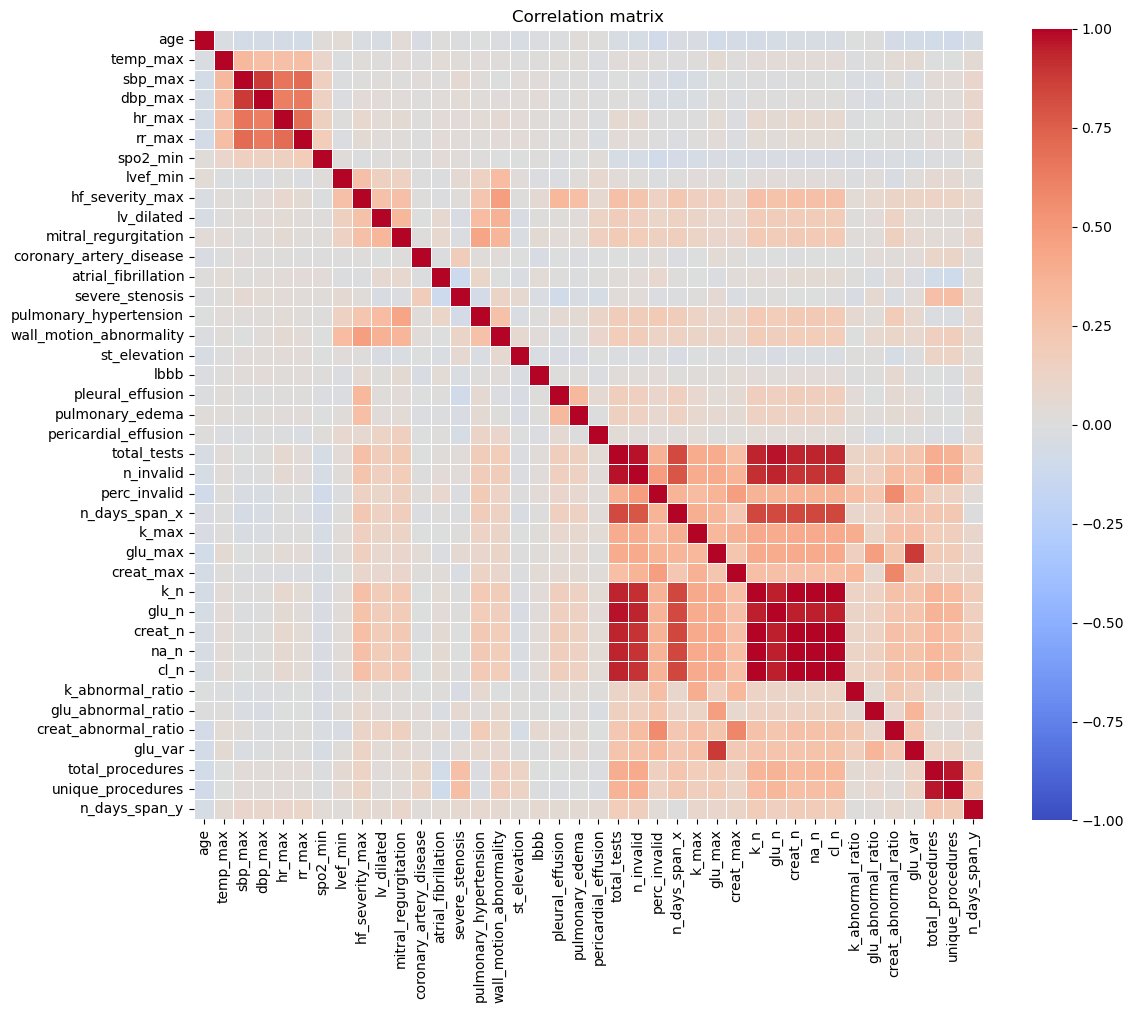

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [23]:
features_to_remove = set()
for _, row in high_corr.iterrows():
    features_to_remove.add(row['feature_2'])

print(f"\nRedundant features ({len(features_to_remove)}):")
for feature in sorted(features_to_remove):
    print(f"  - {feature}")


Redundant features (10):
  - cl_n
  - creat_n
  - dbp_max
  - glu_n
  - glu_var
  - k_n
  - n_days_span_x
  - n_invalid
  - na_n
  - unique_procedures


## Redudant features managing

We need to manage redundant features from the combined dataset, given that they provide the same information of the data we have. 


In [24]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

print(f"Starting features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

#Remove highly correlated features (threshold 0.80)
corr = X.corr()
high_corr = set()
corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.80:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
            high_corr.add(corr.columns[j])  # Remove the second feature

print(f"\nHighly correlated pairs found (|r| > 0.80): {len(corr_pairs)}")
if len(corr_pairs) > 0:
    print("\nSome examples of high correlations:")
    for feat1, feat2, corr_val in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1} <-> {feat2}: {corr_val:.3f}")

print(f"\nFeatures to remove due to high correlation ({len(high_corr)}): {sorted(high_corr)}")

X = X.drop(columns=list(high_corr), errors='ignore')
print(f"\nAfter correlation filter: {X.shape[1]} features")

# Step 4: Create final dataset
final_features = ['subject_id'] + X.columns.tolist()
patient_profile_clean = final_merge[final_features].copy()

Starting features: 43
Features: ['age', 'temp_max', 'sbp_max', 'dbp_max', 'hr_max', 'rr_max', 'spo2_min', 'lvef_min', 'hf_severity_max', 'lv_dilated', 'mitral_regurgitation', 'aortic_stenosis', 'coronary_artery_disease', 'atrial_fibrillation', 'severe_stenosis', 'pulmonary_hypertension', 'wall_motion_abnormality', 'low_cardiac_output', 'st_elevation', 'lbbb', 'pleural_effusion', 'pulmonary_edema', 'pericardial_effusion', 'total_tests', 'n_invalid', 'perc_invalid', 'n_days_span_x', 'k_max', 'glu_max', 'creat_max', 'k_n', 'glu_n', 'creat_n', 'na_n', 'cl_n', 'k_abnormal_ratio', 'glu_abnormal_ratio', 'creat_abnormal_ratio', 'na_cl_ratio', 'glu_var', 'total_procedures', 'unique_procedures', 'n_days_span_y']

Highly correlated pairs found (|r| > 0.80): 30

Some examples of high correlations:
  na_n <-> cl_n: 0.999
  k_n <-> na_n: 0.996
  k_n <-> cl_n: 0.995
  creat_n <-> na_n: 0.994
  creat_n <-> cl_n: 0.994
  k_n <-> creat_n: 0.994
  total_tests <-> glu_n: 0.971
  total_tests <-> n_invalid:

# Missing values

Keeping track of missing values on final dataset is important

In [25]:
missing_counts = patient_profile_clean.isna().sum()
missing_pct = (missing_counts / len(patient_profile_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

In [26]:
missing_df[missing_df['Missing_Pct'] > 0].shape

(10, 3)

In [27]:
missing_df[missing_df['Missing_Pct'] > 0].head(15)

,Feature,Missing_Count,Missing_Pct
30,n_days_span_y,1060,24.71
29,total_procedures,1060,24.71
25,creat_max,8,0.19
22,perc_invalid,8,0.19
21,total_tests,8,0.19
23,k_max,8,0.19
24,glu_max,8,0.19
26,k_abnormal_ratio,8,0.19
28,creat_abnormal_ratio,8,0.19
27,glu_abnormal_ratio,8,0.19


In [28]:
patient_profile_clean[final_features].describe()

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,...,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
count,4.289000e+03,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,...,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,4281.000000,3229.000000,3229.000000
mean,1.500975e+07,20.286547,61.774120,67.002565,38.876195,9.000933,78.976685,13.439030,0.807647,0.413150,...,197.725531,0.327328,4.674422,171.947676,1.738379,0.048457,0.650986,0.382607,4.489625,44.392691
std,2.880712e+06,32.418493,99.414697,67.379766,43.672963,10.009021,43.645546,21.730929,1.279166,0.492457,...,224.556898,0.124936,0.690724,86.954167,1.647058,0.118888,0.346540,0.440036,3.310684,260.791285
min,1.000098e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.249274e+07,0.000000,0.000000,0.000000,0.000000,0.000000,93.000000,0.000000,0.000000,0.000000,...,74.000000,0.241000,4.300000,115.000000,1.000000,0.000000,0.400000,0.000000,2.000000,0.000000
50%,1.499043e+07,0.000000,96.000000,93.000000,0.000000,0.000000,96.000000,0.000000,0.000000,0.000000,...,129.000000,0.331000,4.600000,148.000000,1.200000,0.000000,0.750000,0.077000,4.000000,0.000000
75%,1.750544e+07,53.000000,98.000000,130.000000,76.000000,18.000000,98.000000,30.000000,1.000000,1.000000,...,244.000000,0.415000,4.900000,199.000000,1.800000,0.000000,1.000000,1.000000,6.000000,2.000000
max,1.999850e+07,95.000000,5100.000000,259.000000,660.000000,95.000000,994.000000,80.000000,9.000000,1.000000,...,3737.000000,1.000000,9.700000,900.000000,18.100000,1.000000,1.000000,1.000000,28.000000,3581.000000


# Outlier detection

In [29]:
from scipy import stats

outliers_summary = []
for col in final_features:
    if patient_profile_clean[col].notna().sum() > 0:
        z_scores = np.abs(stats.zscore(patient_profile_clean[col].dropna()))
        outlier_count = (z_scores > 3).sum()
        if outlier_count > 0:
            outliers_summary.append({
                'Feature': col,
                'Outliers': outlier_count,
                'Outliers_Pct': (outlier_count / len(final_merge) * 100).round(2)
            })

outliers_df = pd.DataFrame(outliers_summary).sort_values('Outliers_Pct', ascending=False)
print(outliers_df.head(10))

                    Feature  Outliers  Outliers_Pct
9           pulmonary_edema       206          4.80
8                      lbbb       184          4.29
7              st_elevation       169          3.94
5           hf_severity_max       122          2.84
14                creat_max       117          2.73
6   coronary_artery_disease       114          2.66
15         k_abnormal_ratio        96          2.24
10              total_tests        79          1.84
13                  glu_max        74          1.73
12                    k_max        69          1.61


Finally, we can save the cleaned patient profiles dataset 

## Saving the features

In [30]:
# Save the cleaned dataset
patient_profile_clean.to_csv(FEATURE_PATH / 'patient_profile_clustering.csv', index=False)
print(f"\nCleaned dataset saved to 'patient_profile_clustering.csv'")


Cleaned dataset saved to 'patient_profile_clustering.csv'
